# Visualize all AEMET station list

In [1]:
from src.DatacubeValidation.stations import get_all_aemet_stations_geodataframe

all_stations = get_all_aemet_stations_geodataframe()
all_stations

2025-07-04 12:18:51.686 | INFO     | src.config:<module>:13 - PROJ_ROOT path is: C:\Workspace\Projects\GAIA\Repos\IberFire


,INDICATIVO,INDSINOP,NOMBRE,PROVINCIA,LATITUD,LONGITUD,ALTURA,FECHA_INICIO,FECHA_FIN,geometry,X_COORDINATE,Y_COORDINATE
0,1387E,8002.0,A CORUÑA AEROPUERTO,A CORUÑA,43.306944,-8.371944,98,1971-12-01,2025-03-07,POINT (2843291.427 2426529.842),2.843291e+06,2.426530e+06
1,1387,8001.0,A CORUÑA,A CORUÑA,43.365833,-8.421389,57,1930-10-01,2025-03-07,POINT (2840902.068 2433887.372),2.840902e+06,2.433887e+06
2,1393,8006.0,CABO VILÁN,A CORUÑA,43.160556,-9.210833,50,1994-01-01,2025-03-07,POINT (2773600.84 2427672.537),2.773601e+06,2.427673e+06
3,1351,8004.0,ESTACA DE BARES,A CORUÑA,43.786111,-7.685000,90,1961-01-01,2025-03-07,POINT (2909068.006 2465190.68),2.909068e+06,2.465191e+06
4,1400,8040.0,FISTERRA,A CORUÑA,42.924722,-9.291389,230,1951-01-01,2025-03-07,POINT (2761027.249 2403859.806),2.761027e+06,2.403860e+06
...,...,...,...,...,...,...,...,...,...,...,...,...
942,9975X,NaN,RASQUERA,TARRAGONA,41.005000,0.613611,112,2009-04-02,2025-03-08,POINT (3530147.403 2038632.968),3.530147e+06,2.038633e+06
943,9988B,8936.0,CAP DE VAQUÈIRA,LLEIDA,42.691944,0.973889,2467,2017-01-01,2025-03-08,POINT (3581037.161 2220639.323),3.581037e+06,2.220639e+06
944,9994X,NaN,BOSSÒST,LLEIDA,42.776111,0.689722,722,2009-07-16,2025-03-08,POINT (3558951.167 2232747.865),3.558951e+06,2.232748e+06
945,9995Y,NaN,VALCARLOS/LUZAIDE,NAVARRA,43.091111,-1.300833,334,2009-07-01,2025-03-08,POINT (3402195.937 2289676.198),3.402196e+06,2.289676e+06


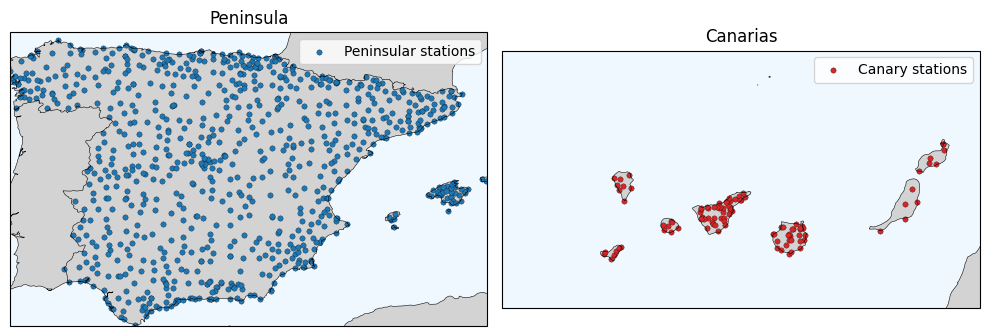

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()            

stations_ll = all_stations.to_crs(4326) # EPSG:4326 → lon/lat

fig, axes = plt.subplots(
    1, 2, figsize=(10, 5),
    subplot_kw={'projection': proj}    
)

def add_basemap(ax):
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS,  linewidth=0.4)

add_basemap(axes[0])

axes[0].scatter(
    stations_ll.geometry.x, stations_ll.geometry.y,
    s=15, color="tab:blue", edgecolors="k", linewidths=0.2,
    label="Peninsular stations",
    transform=proj                # because points are lon/lat
)
axes[0].set_extent([-9, 4, 36, 44], crs=proj)   # [west, east, south, north]
axes[0].legend()
axes[0].set_title("Peninsula")

add_basemap(axes[1])

axes[1].scatter(
    stations_ll.geometry.x, stations_ll.geometry.y,
    s=15, color="tab:red", edgecolors="k", linewidths=0.2,
    label="Canary stations",
    transform=proj
)
axes[1].set_extent([-19.5, -13, 27, 30.5], crs=proj)
axes[1].legend()
axes[1].set_title("Canarias")

plt.tight_layout()
plt.show()


# Visualize valid AEMET station list (the ones inside IberFire's range)

In [3]:
from src.DatacubeValidation.stations import get_valid_aemet_stations_geodataframe

valid_stations = get_valid_aemet_stations_geodataframe()
valid_stations

,INDICATIVO,INDSINOP,NOMBRE,PROVINCIA,LATITUD,LONGITUD,ALTURA,FECHA_INICIO,FECHA_FIN,geometry,X_COORDINATE,Y_COORDINATE
0,1387E,8002.0,A CORUÑA AEROPUERTO,A CORUÑA,43.306944,-8.371944,98,1971-12-01,2025-03-07,POINT (2843291.427 2426529.842),2.843291e+06,2.426530e+06
1,1387,8001.0,A CORUÑA,A CORUÑA,43.365833,-8.421389,57,1930-10-01,2025-03-07,POINT (2840902.068 2433887.372),2.840902e+06,2.433887e+06
2,1393,8006.0,CABO VILÁN,A CORUÑA,43.160556,-9.210833,50,1994-01-01,2025-03-07,POINT (2773600.84 2427672.537),2.773601e+06,2.427673e+06
3,1351,8004.0,ESTACA DE BARES,A CORUÑA,43.786111,-7.685000,90,1961-01-01,2025-03-07,POINT (2909068.006 2465190.68),2.909068e+06,2.465191e+06
4,1400,8040.0,FISTERRA,A CORUÑA,42.924722,-9.291389,230,1951-01-01,2025-03-07,POINT (2761027.249 2403859.806),2.761027e+06,2.403860e+06
...,...,...,...,...,...,...,...,...,...,...,...,...
942,9975X,NaN,RASQUERA,TARRAGONA,41.005000,0.613611,112,2009-04-02,2025-03-08,POINT (3530147.403 2038632.968),3.530147e+06,2.038633e+06
943,9988B,8936.0,CAP DE VAQUÈIRA,LLEIDA,42.691944,0.973889,2467,2017-01-01,2025-03-08,POINT (3581037.161 2220639.323),3.581037e+06,2.220639e+06
944,9994X,NaN,BOSSÒST,LLEIDA,42.776111,0.689722,722,2009-07-16,2025-03-08,POINT (3558951.167 2232747.865),3.558951e+06,2.232748e+06
945,9995Y,NaN,VALCARLOS/LUZAIDE,NAVARRA,43.091111,-1.300833,334,2009-07-01,2025-03-08,POINT (3402195.937 2289676.198),3.402196e+06,2.289676e+06


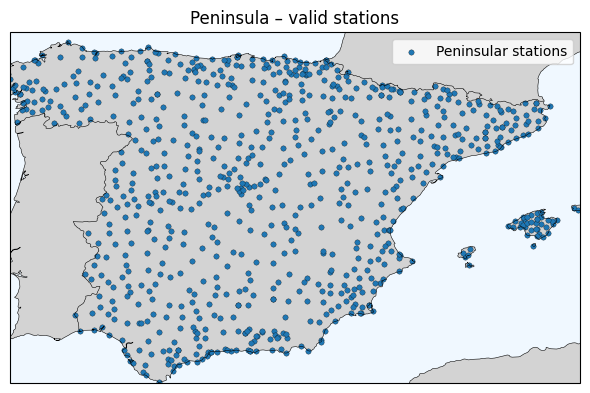

In [4]:
proj = ccrs.PlateCarree()        

stations_ll = valid_stations.to_crs(4326)      

fig, ax = plt.subplots(
    1, 1, figsize=(6, 6),
    subplot_kw={"projection": proj}
)

def add_basemap(ax):
    # ── Base fill ───────────────────────────────────────
    ax.add_feature(cfeature.LAND,  facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4)

add_basemap(ax)

ax.scatter(
    stations_ll.geometry.x, stations_ll.geometry.y,
    s=15, color="tab:blue", edgecolors="k", linewidths=0.2,
    label="Peninsular stations",
    transform=proj
)

ax.set_extent([-9, 4, 36, 44], crs=proj)   
ax.legend()
ax.set_title("Peninsula – valid stations")

plt.tight_layout()
plt.show()


# Visualize data from one AEMET station

In [5]:
from src.DatacubeValidation.stations import get_aemet_station_data_from_id
station_INDICATIVO = "1014A" # Aeropuerto Hondarribia

df = get_aemet_station_data_from_id(station_INDICATIVO)
df

,FECHA,INDICATIVO,NOMBRE,PROVINCIA,ALTITUD,TMEDIA,PRECIPITACION,TMIN,HORATMIN,TMAX,HORATMAX,DIR,VELMEDIA,RACHA,HORARACHA,SOL,PRESMAX,HORAPRESMAX,PRESMIN,HORAPRESMIN
0,2011-11-01,1014A,DONOSTIA / SAN SEBASTIÁN AEROPUERTO,GIPUZKOA,4,16.5,0.0,12.9,21:14,20.1,23:57,29.0,1.9,11.7,00:07,5.1,1016.7,Varias,1009.2,24
1,2011-11-02,1014A,DONOSTIA / SAN SEBASTIÁN AEROPUERTO,GIPUZKOA,4,21.2,0.0,19.9,00:10,22.6,12:17,99.0,5.8,25.8,Varias,0.6,1009.2,00,995.2,23
2,2011-11-03,1014A,DONOSTIA / SAN SEBASTIÁN AEROPUERTO,GIPUZKOA,4,18.4,0.0,15.3,23:48,21.5,08:52,21.0,6.7,24.7,00:19,2.0,996.4,Varias,992.6,12
3,2011-11-04,1014A,DONOSTIA / SAN SEBASTIÁN AEROPUERTO,GIPUZKOA,4,15.9,27.4,12.6,23:19,19.2,12:34,20.0,2.5,20.6,02:12,1.8,998.3,Varias,994.6,13
4,2011-11-05,1014A,DONOSTIA / SAN SEBASTIÁN AEROPUERTO,GIPUZKOA,4,13.0,45.7,11.2,07:40,14.7,23:26,36.0,2.2,16.9,23:51,0.0,1010.9,Varias,998.3,00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4805,2024-12-27,1014A,DONOSTIA / SAN SEBASTIÁN AEROPUERTO,GIPUZKOA,4,9.0,Ip,4.6,23:25,13.4,14:48,99.0,1.7,4.2,Varias,2.3,1030.0,Varias,1026.9,15
4806,2024-12-28,1014A,DONOSTIA / SAN SEBASTIÁN AEROPUERTO,GIPUZKOA,4,9.1,Ip,2.7,07:36,15.5,11:23,13.0,2.2,4.7,08:26,6.9,1030.6,Varias,1027.7,01
4807,2024-12-29,1014A,DONOSTIA / SAN SEBASTIÁN AEROPUERTO,GIPUZKOA,4,9.4,Ip,4.0,23:40,14.8,14:46,14.0,1.9,6.1,08:29,6.2,1030.6,Varias,1028.8,14
4808,2024-12-30,1014A,DONOSTIA / SAN SEBASTIÁN AEROPUERTO,GIPUZKOA,4,7.0,Ip,2.6,03:32,11.4,13:50,99.0,1.9,4.7,Varias,5.9,1030.4,Varias,1028.0,14


# Number of records in each station

In [6]:
n_instances = []
for i, row in valid_stations.iterrows():
    station_INDICATIVO = row["INDICATIVO"]
    n_instances.append(get_aemet_station_data_from_id(station_INDICATIVO).shape[0])
valid_stations["n_instances"] = n_instances

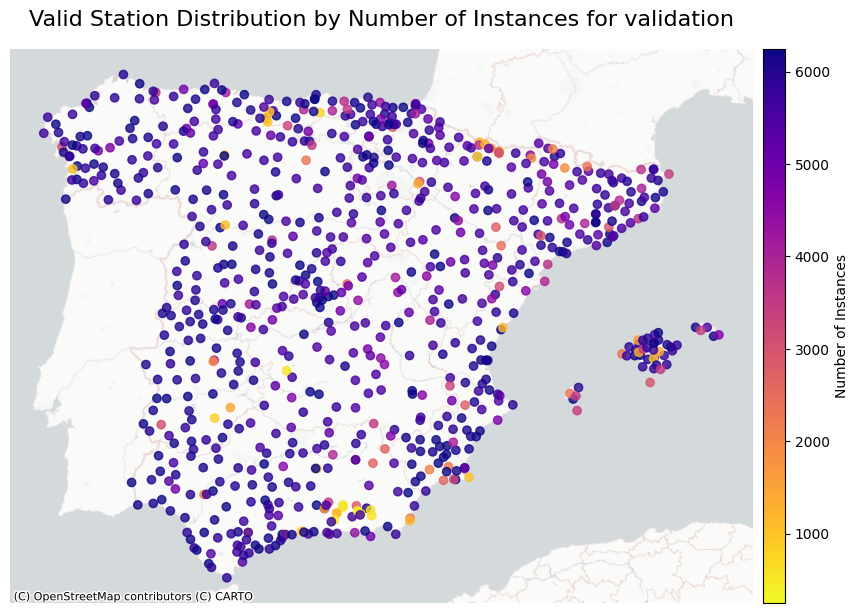

In [7]:
import matplotlib.pyplot as plt
import contextily as ctx
from mpl_toolkits.axes_grid1 import make_axes_locatable
from src.config import FIGURES_DIR

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)  

valid_stations = valid_stations.to_crs(epsg=3857)  # Change crs for plotting

valid_stations.plot(
    column="n_instances", 
    cmap="plasma_r",  
    legend=True, 
    ax=ax, 
    legend_kwds={'label': "Number of Instances", 'orientation': "vertical"},
    alpha=0.8, 
    cax=cax  
)

ctx.add_basemap(ax, crs=valid_stations.crs.to_string(), source=ctx.providers.CartoDB.PositronNoLabels)

ax.set_title("Valid Station Distribution by Number of Instances for validation", fontsize=16)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

ax.set_axis_off()  

plt.savefig(FIGURES_DIR / "station_distribution.png", dpi=300, bbox_inches="tight")

plt.show()
